# Transformer Encoder para clasificación de sentimiento en reseñas de Amazon (ES)

Este notebook implementa desde cero, en PyTorch, un Transformer Encoder para clasificar reseñas de Amazon en español (`mteb/amazon_reviews_multi`) en tres clases: **negativo** (1-2 estrellas), **neutro** (3 estrellas) y **positivo** (4-5 estrellas).

Es un caso propio, inspirado en el notebook guía `1-transformers-from-scratch.ipynb` (que clasifica noticias) pero pensado desde cero para este problema. El dataset es deliberadamente el mismo que usamos en el proyecto anterior de LSTM/BiLSTM, para poder comparar arquitecturas de forma controlada.

**Cómo está organizado:**

0. EDA del tokenizer — decidir `vocab_size` y `MAX_LEN` con datos, no por intuición.
1. Arquitectura final del Transformer, con la justificación de cada decisión.
2. Splits oficiales y el pipeline de datos en PyTorch.
3. Baselines (TF-IDF+LogReg como referencia externa, MLP entrenado aquí).
4. El Transformer Encoder propio.
5. Utilidades de entrenamiento y evaluación.
6. Experimentos: E1 (pipeline mínimo), E2 (cantidad de datos), E3 (pooling), E4 (warmup de learning rate), E5 (capacidad).
7. Evaluación final en test y análisis de errores.
8. Conclusiones.

Cada experimento deja su hipótesis, qué se mantuvo fijo y qué se concluyó con los números reales — incluidos los que no mejoraron nada, porque también enseñan algo.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IN_COLAB

True

In [2]:
if IN_COLAB:
    # -U fuerza a pip a resolver versiones mutuamente compatibles. Sin esto, Colab
    # se queda con una version vieja de `tokenizers` que no soporta parametros que
    # la version nueva de `transformers` ya da por sentado (p.ej. `enable_truncation
    # (direction=...)`), lo que revienta con TypeError apenas se tokeniza con padding.
    !pip install -q -U datasets tokenizers transformers huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 50.5 MB/s eta 0:00:00


In [3]:
#Importación de librerias
import os
import re
import math
import random
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader

from datasets import Dataset
from huggingface_hub import hf_hub_download
from tokenizers import Tokenizer, trainers, pre_tokenizers, decoders, processors
from tokenizers.models import BPE
from transformers import PreTrainedTokenizerFast

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Evita que el tokenizer intente paralelizar con fork despues de que DataLoader ya
# está usando multiprocessing (num_workers>0) -- si no, tira warnings y en el peor caso se cuelga.
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: cuda


## Sección 0: Tokenizer propio y EDA de tokenización

Antes de fijar la arquitectura necesitamos decidir, con datos y no por intuición, dos cosas: cuántas piezas de subpalabra va a tener el vocabulario (`vocab_size`) y cuántos tokens va a admitir cada secuencia (`MAX_LEN`).

A diferencia del LSTM, donde el vocabulario era por palabra completa y "cobertura %" era la métrica natural, acá con BPE cualquier palabra es representable partiéndola en piezas más chicas — no hay problema de OOV en ese sentido. Lo que cambia con `vocab_size` es la **fertility** (tokens promedio por palabra): más vocabulario da tokens más "completos" a costa de una tabla de embeddings más grande. Ese es el trade-off que exploramos abajo.

**Todo lo de esta sección usa solo el split de `train`**, para que estas decisiones no dependan de nada visto en validation o test.

### Carga del dataset (train)

In [4]:
def load_split(split_name: str) -> Dataset:
    path = hf_hub_download(
        repo_id="mteb/amazon_reviews_multi",
        repo_type="dataset",
        revision="refs/convert/parquet",
        filename=f"es/{split_name}/0000.parquet",
    )
    df = pd.read_parquet(path)
    return Dataset.from_pandas(df, preserve_index=False)


train_raw = load_split("train")
train_raw

es/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 24.6MB            

es/train/0000.parquet: downloading bytes:           |  0.00B            

Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 200000
})

### Construcción de las 3 clases

Mismo criterio que el LSTM: `label` original va de 0 a 4 (1 a 5 estrellas), y agrupamos:

- `label` 0-1 (1-2 estrellas) → **negativo** (0)
- `label` 2 (3 estrellas) → **neutro** (1)
- `label` 3-4 (4-5 estrellas) → **positivo** (2)

In [5]:
def stars_to_sentiment(example):
    label = example['label']  # 0..4 == 1..5 estrellas
    if label <= 1:
        sentiment = 0  # negativo
    elif label == 2:
        sentiment = 1  # neutro
    else:
        sentiment = 2  # positivo
    return {'sentiment': sentiment}


train_raw = train_raw.map(stars_to_sentiment)
collections.Counter(train_raw['sentiment'])

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Counter({0: 80000, 1: 40000, 2: 80000})

La clase `neutro` debería salir con aproximadamente la mitad de ejemplos que `negativo`/`positivo`, tal como se documentó en el EDA del LSTM.

### Entrenando un tokenizer de subpalabras desde cero

El notebook guía parte del vocabulario de GPT-2, entrenado sobre texto general. Nosotros entrenamos un BPE byte-level completamente desde cero sobre este corpus, para que el vocabulario refleje el lenguaje real de las reseñas: coloquialismos, errores de tipeo, vocabulario de producto/precio/calidad.

In [6]:
def train_bpe_tokenizer(texts, vocab_size: int, min_frequency: int = 2) -> PreTrainedTokenizerFast:

    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()
    tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)

    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=min_frequency,
        special_tokens=['[PAD]', '[UNK]', '[CLS]'],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    )
    tokenizer.train_from_iterator(texts, trainer=trainer)

    return PreTrainedTokenizerFast(
        tokenizer_object=tokenizer,
        unk_token='[UNK]',
        pad_token='[PAD]',
        cls_token='[CLS]',
    )

### Análisis de fertility para elegir `vocab_size`

Entrenamos tokenizers candidatos sobre una muestra de train (el entrenador de BPE es rápido y una muestra grande ya es representativa) y medimos, sobre un conjunto de evaluación separado, cuántos tokens produce cada candidato por palabra.

In [7]:
SAMPLE_SIZE_TRAIN_TOKENIZER = 50_000
EVAL_SAMPLE_SIZE = 5_000

rng = np.random.default_rng(SEED)
shuffled_idx = rng.permutation(len(train_raw))
tokenizer_train_idx = shuffled_idx[:SAMPLE_SIZE_TRAIN_TOKENIZER]
fertility_eval_idx = shuffled_idx[SAMPLE_SIZE_TRAIN_TOKENIZER:SAMPLE_SIZE_TRAIN_TOKENIZER + EVAL_SAMPLE_SIZE]


tokenizer_train_texts = list(train_raw.select(tokenizer_train_idx)['text'])
fertility_eval_texts = list(train_raw.select(fertility_eval_idx)['text'])


def word_count(text: str) -> int:
    return len(re.findall(r"\S+", text))


total_words_eval = sum(word_count(t) for t in fertility_eval_texts)
total_words_eval

158143

In [8]:
VOCAB_SIZE_CANDIDATES = [8_000, 12_000, 16_000, 20_000, 24_000, 32_000]

fertility_results = []
for vocab_size in VOCAB_SIZE_CANDIDATES:
    tok = train_bpe_tokenizer(tokenizer_train_texts, vocab_size=vocab_size)
    encoded = tok(fertility_eval_texts)['input_ids']
    total_tokens = sum(len(ids) for ids in encoded)
    fertility = total_tokens / total_words_eval
    fertility_results.append({'vocab_size': vocab_size, 'total_tokens': total_tokens, 'fertility': fertility})
    print(f"vocab_size={vocab_size:>6} -> fertility={fertility:.3f} tokens/palabra")

fertility_df = pd.DataFrame(fertility_results)
fertility_df

vocab_size=  8000 -> fertility=1.326 tokens/palabra
vocab_size= 12000 -> fertility=1.278 tokens/palabra
vocab_size= 16000 -> fertility=1.252 tokens/palabra
vocab_size= 20000 -> fertility=1.236 tokens/palabra
vocab_size= 24000 -> fertility=1.226 tokens/palabra
vocab_size= 32000 -> fertility=1.214 tokens/palabra


,vocab_size,total_tokens,fertility
0,8000,209701,1.326021
1,12000,202063,1.277723
2,16000,198028,1.252208
3,20000,195503,1.236242
4,24000,193927,1.226276
5,32000,191913,1.213541


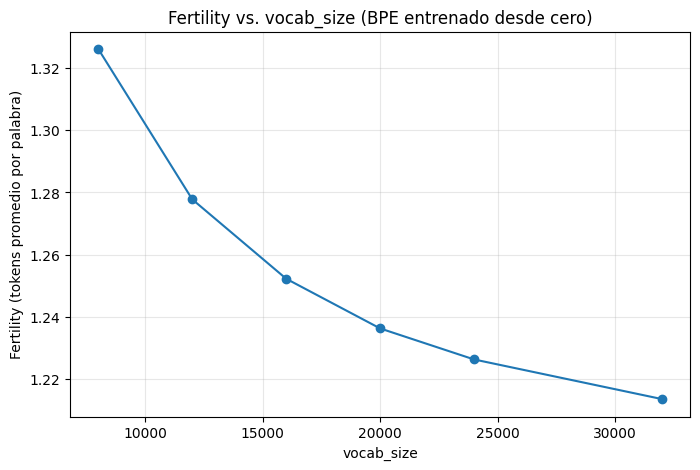

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(fertility_df['vocab_size'], fertility_df['fertility'], marker='o')
plt.xlabel('vocab_size')
plt.ylabel('Fertility (tokens promedio por palabra)')
plt.title('Fertility vs. vocab_size (BPE entrenado desde cero)')
plt.grid(alpha=0.3)
plt.show()

### Decisión: `vocab_size`

La curva de fertility tiene retornos claramente decrecientes: de 8k a 12k la fertility baja 0.048, pero de 24k a 32k (el doble de vocabulario extra) baja solo 0.013. El codo cae entre 16k y 20k. Nos quedamos con **20,000**: además de caer justo donde la curva ya se aplanó, coincide con el `MAX_VOCAB=20000` que usó el LSTM, así que la comparación entre arquitecturas no queda sesgada por el tamaño del vocabulario.

In [10]:
VOCAB_SIZE_FINAL = 20_000

### Tokenizer final y EDA de longitud en tokens

Con `VOCAB_SIZE_FINAL` decidido, entrenamos el tokenizer definitivo sobre **todo** train (no solo la muestra) y medimos la distribución de longitud en tokens, con el mismo criterio de percentil 95 que usó el LSTM para `MAX_LEN`.

In [11]:
final_tokenizer = train_bpe_tokenizer(list(train_raw['text']), vocab_size=VOCAB_SIZE_FINAL)
len(final_tokenizer)

20000

In [12]:
TOKEN_LENGTH_SAMPLE_SIZE = 20_000  # no hace falta tokenizar los 200k completos para estimar percentiles

length_sample_idx = rng.permutation(len(train_raw))[:TOKEN_LENGTH_SAMPLE_SIZE]
length_sample_texts = list(train_raw.select(length_sample_idx)['text'])

token_lengths = np.array([len(ids) for ids in final_tokenizer(length_sample_texts)['input_ids']])

percentiles = [50, 75, 90, 95, 99, 100]
length_percentiles = {p: int(np.percentile(token_lengths, p)) for p in percentiles}
length_percentiles

{50: 31, 75: 46, 90: 69, 95: 89, 99: 148, 100: 532}

Comparando contra los percentiles en **palabras** del LSTM (p95=76, p99=127): como era de esperar dado que la fertility del tokenizer es >1.0 (~1.24 a `vocab_size=20000`), los percentiles en tokens salen más altos que en palabras — cada review necesita algunos tokens de más porque el BPE parte las palabras menos frecuentes.

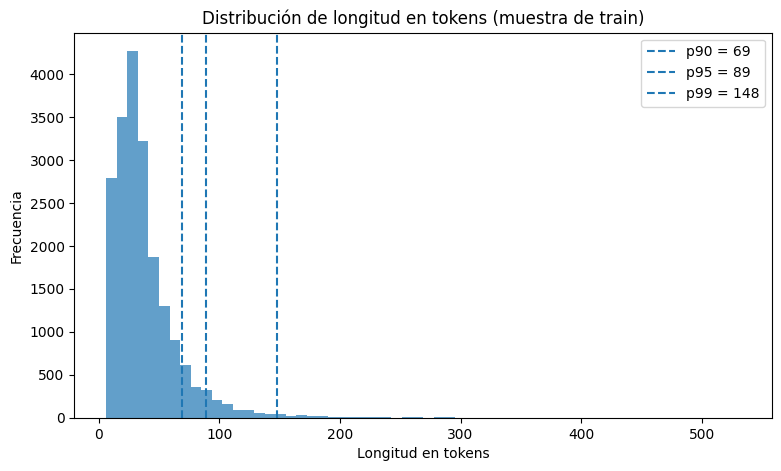

In [13]:
plt.figure(figsize=(9, 5))
plt.hist(token_lengths, bins=60, alpha=0.7)
for p in [90, 95, 99]:
    plt.axvline(length_percentiles[p], linestyle='--', label=f'p{p} = {length_percentiles[p]}')
plt.xlabel('Longitud en tokens')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud en tokens (muestra de train)')
plt.legend()
plt.show()

In [14]:
MAX_LEN_CANDIDATES = sorted(set([length_percentiles[75], length_percentiles[90], length_percentiles[95], length_percentiles[99]]))

for max_len in MAX_LEN_CANDIDATES:
    pct_truncated = (token_lengths > max_len).mean() * 100
    print(f"MAX_LEN={max_len:>4} -> {pct_truncated:.2f}% de reseñas truncadas (en la muestra)")

MAX_LEN=  46 -> 24.93% de reseñas truncadas (en la muestra)
MAX_LEN=  69 -> 9.99% de reseñas truncadas (en la muestra)
MAX_LEN=  89 -> 4.95% de reseñas truncadas (en la muestra)
MAX_LEN= 148 -> 1.00% de reseñas truncadas (en la muestra)


### Decisión: `MAX_LEN`

Con `percentiles = {50: 31, 75: 46, 90: 69, 95: 89, 99: 148, 100: 532}`, nos quedamos con el percentil 95: **89 tokens**, dejando 4.95% de reseñas truncadas — mismo criterio que el LSTM (p95=76 palabras). Llegar a p99=148 solo suma 4 puntos de cobertura pero casi triplica el costo de self-attention (O(L^2): 148^2/89^2 ~= 2.77x), por una cola larga (hasta 532 tokens) de casos raros que no vale la pena arrastrar en toda secuencia.

In [15]:
MAX_LEN_FINAL = 89

## Sección 1: Arquitectura final del Transformer Encoder

Con `vocab_size` y `MAX_LEN` ya decididos con datos, esto es el resto de la configuración base y por qué:

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `vocab_size` | 20,000 | EDA de fertility (Sección 0) |
| `MAX_LEN` | 89 | Percentil 95 de longitud en tokens (Sección 0) |
| `d_model` | 128 | Mismo orden que el notebook guía; alcanza para 3 clases sin sobrar |
| `num_heads` | 4 | 128/4 = 32 dim por cabeza, un tamaño de proyección razonable |
| `num_layers` | 2 | Encoder poco profundo pero real (stack), no un solo bloque como la guía |
| `d_ff` | 512 | 4x `d_model`, la proporción del paper original |
| `dropout` | 0.1 | Con 40k-200k ejemplos el dataset sigue siendo chico para un Transformer |
| Pooling | mean enmascarado | Ignora `[PAD]`; comparable al mean-pooling que le funcionó mejor al BiLSTM |
| Positional encoding | sinusoidal | Sin parámetros extra, tal cual el paper |

Esta implementación corrige tres cosas del notebook guía que no son fieles al paper original:
- **Conexiones residuales** en cada sub-capa (`LayerNorm(x + Sublayer(x))`), ausentes en la guía.
- **Máscara de padding real** (`-inf` efectivo, no `-9e-15`, que en la práctica no bloquea nada).
- **Pooling explícito** en vez de `Flatten`, que le generaba a la guía un classifier de 134M de parámetros inútiles.

In [16]:
# Config final, usada por todos los experimentos de acá en adelante.
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 512
DROPOUT = 0.1
MAX_LEN = MAX_LEN_FINAL

BATCH_SIZE = 64
NUM_EPOCHS = 10
CLASS_NAMES = ['negativo', 'neutro', 'positivo']

## Sección 2: Splits oficiales y Dataset de PyTorch

Cargamos validation y test (los splits oficiales, no un split aleatorio propio como en la guía) para evitar cualquier fuga de datos y poder comparar directo contra las métricas que reportó el LSTM.

In [17]:
val_raw = load_split("validation").map(stars_to_sentiment)
test_raw = load_split("test").map(stars_to_sentiment)
len(val_raw), len(test_raw)

0000.parquet:   0%|          | 0.00/613k [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

0000.parquet:   0%|          | 0.00/619k [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

(5000, 5000)

In [18]:
class SentimentDataset(TorchDataset):
    """Tokeniza on-the-fly con el tokenizer final, con padding/truncado a max_len."""

    def __init__(self, hf_dataset, tokenizer, max_len: int):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]
        enc = self.tokenizer(
            row['text'], max_length=self.max_len, truncation=True, padding='max_length',
        )
        return {
            'input_ids': torch.tensor(enc['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(enc['attention_mask'], dtype=torch.long),
            'label': torch.tensor(row['sentiment'], dtype=torch.long),
        }


def get_train_subset(dataset, n: int, seed: int = SEED):
    local_rng = np.random.default_rng(seed)
    idx = local_rng.permutation(len(dataset))[:n]
    return dataset.select(idx)


def compute_class_weights(labels, num_classes: int = 3):
    counts = collections.Counter(labels)
    total = len(labels)
    weights = [total / (num_classes * counts[c]) for c in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float)

## Sección 3: Baseline TF-IDF + Regresión Logística (referencia externa)

Este baseline **no se reentrena en este notebook** — usamos directamente el resultado que ya reportó el proyecto LSTM.

Los valores de referencia se usan donde corresponda (E1 y la evaluación final en test).

## Sección 4: MLP baseline

El MLP usa la **misma tokenización, vocabulario y dimensión de embedding** que el Transformer (`d_model`), y el mismo mean-pooling enmascarado — pero sin self-attention ni información posicional. La idea es aislar la pregunta que nos interesa: ¿qué aporta el self-attention por sí solo, dejando todo lo demás igual?

In [19]:
class MLPBaseline(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, hidden_dim: int = 256,
                 num_classes: int = 3, dropout: float = 0.1, pad_token_id: int = 0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L, D)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.classifier(pooled)

## Sección 5: Transformer Encoder propio

Implementación propia en PyTorch, inspirada en el notebook guía pero corrigiendo lo que se explica en la Sección 1.

In [20]:
class SinusoidalPositionalEncoding(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1).float()
        i = torch.arange(d_model).unsqueeze(0).float()
        div_term = 1.0 / torch.pow(10000, (2 * (i // 2)) / d_model)
        angles = pos * div_term

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(angles[:, 0::2])
        pe[:, 1::2] = torch.cos(angles[:, 1::2])
        self.register_buffer('pe', pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model debe ser divisible por num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)  # (B, H, L, Dh)

    def forward(self, x, attention_mask=None):
        batch_size, seq_len, _ = x.shape
        q = self._split_heads(self.q_proj(x), batch_size)
        k = self._split_heads(self.k_proj(x), batch_size)
        v = self._split_heads(self.v_proj(x), batch_size)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,H,L,L)

        if attention_mask is not None:
            # attention_mask: (B, L), 1 = token real, 0 = padding. Enmascaramos las
            # KEYS de padding con -inf efectivo antes del softmax -- a diferencia
            # del notebook guia, que usaba -9e-15 y en la practica no enmascaraba nada.
            mask = attention_mask[:, None, None, :].bool()  # (B,1,1,L)
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        context = torch.matmul(attn, v)  # (B,H,L,Dh)
        context = context.permute(0, 2, 1, 3).contiguous().view(batch_size, seq_len, self.d_model)
        return self.out_proj(context), attn


class EncoderLayer(nn.Module):

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, attention_mask=None):
        attn_out, _ = self.self_attn(x, attention_mask)
        x = self.norm1(x + self.dropout1(attn_out))  # residual + LayerNorm (post-LN)
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x


class TransformerEncoder(nn.Module):

    def __init__(self, num_layers: int, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

    def forward(self, x, attention_mask=None):
        for layer in self.layers:
            x = layer(x, attention_mask)
        return x


def masked_mean_pooling(x, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
    summed = (x * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def masked_max_pooling(x, attention_mask):
    mask = attention_mask.unsqueeze(-1).bool()  # (B, L, 1)
    x_masked = x.masked_fill(~mask, float('-inf'))
    pooled, _ = x_masked.max(dim=1)
    return pooled


class TransformerClassifier(nn.Module):
    """pooling: 'mean' (default), 'max', o 'cls'."""

    def __init__(self, vocab_size: int, max_len: int, d_model: int, num_heads: int,
                 num_layers: int, d_ff: int, num_classes: int = 3, dropout: float = 0.1,
                 pad_token_id: int = 0, pooling: str = 'mean'):
        super().__init__()
        assert pooling in ('mean', 'max', 'cls'), "pooling debe ser 'mean', 'max' o 'cls'"
        self.pooling = pooling

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        # Con pooling='cls' se antepone un token [CLS] aprendible a la secuencia,
        # en espacio de embeddings (no se toca el tokenizer) -- por eso el
        # positional encoding necesita una posicion extra en ese caso.
        effective_max_len = max_len + 1 if pooling == 'cls' else max_len
        self.pos_encoding = SinusoidalPositionalEncoding(effective_max_len, d_model)
        self.embedding_dropout = nn.Dropout(dropout)
        self.encoder = TransformerEncoder(num_layers, d_model, num_heads, d_ff, dropout)

        if pooling == 'cls':
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.normal_(self.cls_token, std=0.02)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        x = self.token_embedding(input_ids)
        mask = attention_mask

        if self.pooling == 'cls':
            batch_size = x.size(0)
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            x = torch.cat([cls_tokens, x], dim=1)
            cls_mask = torch.ones(batch_size, 1, dtype=mask.dtype, device=mask.device)
            mask = torch.cat([cls_mask, mask], dim=1)

        x = self.pos_encoding(x)
        x = self.embedding_dropout(x)
        x = self.encoder(x, mask)

        if self.pooling == 'mean':
            pooled = masked_mean_pooling(x, mask)
        elif self.pooling == 'max':
            pooled = masked_max_pooling(x, mask)
        else:  # 'cls'
            pooled = x[:, 0, :]

        return self.classifier(pooled)


def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [21]:
# Chequeo rapido del tamaño del modelo antes de entrenar, con la config base,
# el 90% de los parámetros son la tabla de embeddings (20,000 x 128), no el encoder.
_tmp = TransformerClassifier(
    vocab_size=len(final_tokenizer), max_len=MAX_LEN, d_model=D_MODEL, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, d_ff=D_FF, pad_token_id=final_tokenizer.pad_token_id,
)
print(f"Transformer base config -> {count_params(_tmp):,} parametros entrenables")
del _tmp

Transformer base config -> 2,964,995 parametros entrenables


## Sección 6: Entrenamiento y evaluación

Loop de entrenamiento propio en PyTorch puro (no Lightning, para tener control total), con:
- `AdamW` + `CrossEntropyLoss` ponderado por clase (`neutro` está subrepresentada).
- Early stopping por **F1 macro en validation**, la métrica prioritaria del proyecto.
- El mismo loop sirve para MLP y Transformer: ambos comparten `forward(input_ids, attention_mask)`.

También definimos `build_transformer` y `train_and_report`, dos helpers que encapsulan el patrón instanciar con seed fija, entrenar, evaluar, imprimir, que se repite en cada experimento — sin esto, cada uno terminaba copiando el mismo bloque de código.

In [22]:
def evaluate_model(model, data_loader, criterion=None, device=DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * input_ids.size(0)

            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / len(data_loader.dataset) if criterion is not None else None
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1_macro, all_preds, all_labels


def build_warmup_decay_lambda(warmup_steps: int):
    """Warmup lineal hasta `warmup_steps`, despues decae como 1/sqrt(step) -- la
    forma del schedule del paper original, pero como multiplicador relativo de un
    `lr` pico que elegimos nosotros, para poder comparar directo contra una corrida
    a LR constante con ese mismo pico."""
    def lr_lambda(step):
        step = max(step, 1)
        if step < warmup_steps:
            return step / warmup_steps
        return (warmup_steps / step) ** 0.5
    return lr_lambda


def train_model(model, train_loader, val_loader, num_epochs: int = 10, lr: float = 3e-4,
                 weight_decay: float = 1e-5, class_weights=None, patience: int = 3, device=DEVICE,
                 use_lr_warmup: bool = False, warmup_ratio: float = 0.1):
    model.to(device)
    weights = class_weights.to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if use_lr_warmup:
        total_steps = len(train_loader) * num_epochs
        warmup_steps = max(1, int(warmup_ratio * total_steps))
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, build_warmup_decay_lambda(warmup_steps))

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'lr': []}
    best_val_f1 = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total_loss += loss.item() * input_ids.size(0)

        train_loss = total_loss / len(train_loader.dataset)
        val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch + 1}/{num_epochs} - train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1_macro={val_f1:.4f} "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping en epoch {epoch + 1} (sin mejora en val_f1_macro por {patience} epochs)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def plot_training_curves(history, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train_loss')
    axes[0].plot(history['val_loss'], label='val_loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_title(f'{title} - loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['val_acc'], label='val_acc')
    axes[1].plot(history['val_f1_macro'], label='val_f1_macro')
    axes[1].set_xlabel('epoch')
    axes[1].set_title(f'{title} - val metrics')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion(labels, preds, class_names, title: str):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

In [23]:
def build_transformer(pooling='mean', num_layers=NUM_LAYERS, num_heads=NUM_HEADS, seed=SEED):
    """Instancia el Transformer con la config base. Fijamos la seed justo antes de
    crear el modelo para que, en cada experimento, la unica diferencia real entre
    corridas sea el parametro que estemos variando."""
    torch.manual_seed(seed)
    return TransformerClassifier(
        vocab_size=len(final_tokenizer), max_len=MAX_LEN, d_model=D_MODEL,
        num_heads=num_heads, num_layers=num_layers, d_ff=D_FF, num_classes=3,
        dropout=DROPOUT, pad_token_id=final_tokenizer.pad_token_id, pooling=pooling,
    )


def build_mlp(seed=SEED):
    torch.manual_seed(seed)
    return MLPBaseline(
        vocab_size=len(final_tokenizer), d_model=D_MODEL, hidden_dim=256,
        num_classes=3, dropout=DROPOUT, pad_token_id=final_tokenizer.pad_token_id,
    )


def train_and_report(model, label, loader=None, weights=None, **train_kwargs):
    """Entrena, evalua contra `val_loader` (siempre el mismo, el split oficial de
    validation -- eso no puede cambiar entre experimentos o deja de ser comparable)
    e imprime el resultado. `loader`/`weights` son opcionales por si un experimento
    entrena con un subset de train distinto al de 40k por defecto (ver E2)."""
    loader = loader if loader is not None else train_loader
    weights = weights if weights is not None else class_weights_40k
    model, history = train_model(
        model, loader, val_loader, num_epochs=NUM_EPOCHS, class_weights=weights, **train_kwargs,
    )
    _, acc, f1, preds, labels = evaluate_model(model, val_loader)
    print(f"{label} -> val_acc={acc:.4f} val_f1_macro={f1:.4f}")
    return model, history, acc, f1, preds, labels

## Experimento E1: pipeline mínimo end-to-end

TF-IDF+LogReg (referencia), MLP y Transformer (config base) sobre el mismo subset de **40k** ejemplos de train, evaluados en el split oficial de **validation**. El objetivo acá es confirmar que el pipeline funciona correctamente antes de invertir tiempo de cómputo en el resto de los experimentos.

In [24]:
train_40k = get_train_subset(train_raw, 40_000)
class_weights_40k = compute_class_weights(train_40k['sentiment'])

train_ds = SentimentDataset(train_40k, final_tokenizer, MAX_LEN)
val_ds = SentimentDataset(val_raw, final_tokenizer, MAX_LEN)
test_ds = SentimentDataset(test_raw, final_tokenizer, MAX_LEN)  # no se toca hasta la evaluacion final

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

len(train_40k), len(val_raw), len(test_raw)

(40000, 5000, 5000)

### E1a — TF-IDF + Regresión Logística (referencia externa, LSTM)

In [25]:
# Ver Seccion 3: no se reentrena, usamos el numero ya reportado de LSTM
tfidf_val_acc = 0.7382
tfidf_val_f1 = 0.6960
print(f"TF-IDF + LogReg (referencia LSTM, 40k) -> val_acc={tfidf_val_acc:.4f} val_f1_macro={tfidf_val_f1:.4f}")

TF-IDF + LogReg (referencia LSTM, 40k) -> val_acc=0.7382 val_f1_macro=0.6960


### E1b — MLP baseline

MLP -> 2,593,795 parametros entrenables
Epoch 1/10 - train_loss=0.9424 val_loss=0.8386 val_acc=0.6350 val_f1_macro=0.5985 lr=3.00e-04
Epoch 2/10 - train_loss=0.8170 val_loss=0.7947 val_acc=0.6514 val_f1_macro=0.6249 lr=3.00e-04
Epoch 3/10 - train_loss=0.7563 val_loss=0.7447 val_acc=0.6766 val_f1_macro=0.6462 lr=3.00e-04
Epoch 4/10 - train_loss=0.7122 val_loss=0.7147 val_acc=0.6914 val_f1_macro=0.6594 lr=3.00e-04
Epoch 5/10 - train_loss=0.6763 val_loss=0.7031 val_acc=0.6980 val_f1_macro=0.6684 lr=3.00e-04
Epoch 6/10 - train_loss=0.6460 val_loss=0.6855 val_acc=0.7034 val_f1_macro=0.6693 lr=3.00e-04
Epoch 7/10 - train_loss=0.6194 val_loss=0.6824 val_acc=0.7064 val_f1_macro=0.6728 lr=3.00e-04
Epoch 8/10 - train_loss=0.5944 val_loss=0.6920 val_acc=0.6996 val_f1_macro=0.6712 lr=3.00e-04
Epoch 9/10 - train_loss=0.5702 val_loss=0.6921 val_acc=0.7022 val_f1_macro=0.6707 lr=3.00e-04
Epoch 10/10 - train_loss=0.5480 val_loss=0.7059 val_acc=0.6954 val_f1_macro=0.6666 lr=3.00e-04
Early stopping en e

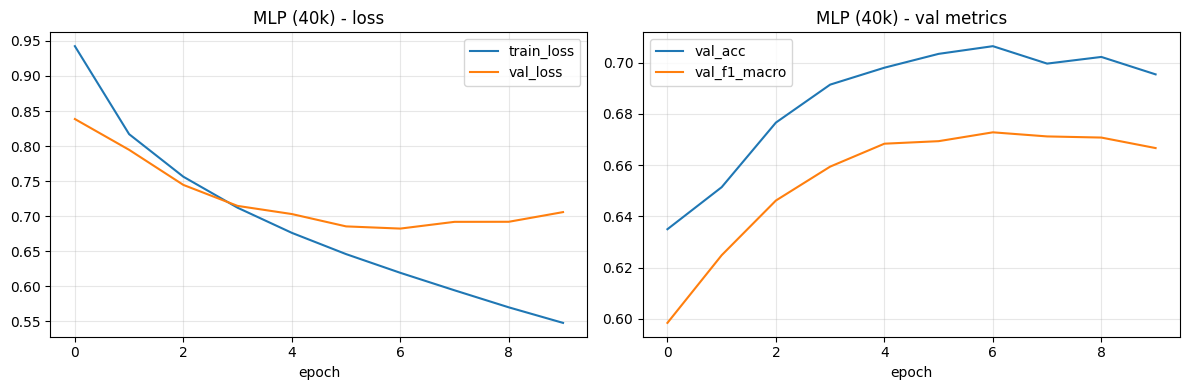

In [26]:
mlp_model = build_mlp()
print(f"MLP -> {count_params(mlp_model):,} parametros entrenables")

mlp_model, mlp_history, mlp_val_acc, mlp_val_f1, mlp_val_preds, mlp_val_labels = train_and_report(
    mlp_model, "MLP (40k)",
)
plot_training_curves(mlp_history, 'MLP (40k)')

### E1c — Transformer Encoder (config base)

Transformer -> 2,964,995 parametros entrenables
Epoch 1/10 - train_loss=0.8849 val_loss=0.7505 val_acc=0.6682 val_f1_macro=0.6385 lr=3.00e-04
Epoch 2/10 - train_loss=0.7640 val_loss=0.7394 val_acc=0.6608 val_f1_macro=0.6413 lr=3.00e-04
Epoch 3/10 - train_loss=0.7202 val_loss=0.6625 val_acc=0.7174 val_f1_macro=0.6742 lr=3.00e-04
Epoch 4/10 - train_loss=0.6913 val_loss=0.6544 val_acc=0.7290 val_f1_macro=0.6798 lr=3.00e-04
Epoch 5/10 - train_loss=0.6636 val_loss=0.6569 val_acc=0.7236 val_f1_macro=0.6786 lr=3.00e-04
Epoch 6/10 - train_loss=0.6402 val_loss=0.6578 val_acc=0.7060 val_f1_macro=0.6790 lr=3.00e-04
Epoch 7/10 - train_loss=0.6137 val_loss=0.6585 val_acc=0.7100 val_f1_macro=0.6801 lr=3.00e-04
Epoch 8/10 - train_loss=0.5954 val_loss=0.6424 val_acc=0.7310 val_f1_macro=0.6915 lr=3.00e-04
Epoch 9/10 - train_loss=0.5741 val_loss=0.6642 val_acc=0.7206 val_f1_macro=0.6837 lr=3.00e-04
Epoch 10/10 - train_loss=0.5494 val_loss=0.6804 val_acc=0.7116 val_f1_macro=0.6789 lr=3.00e-04
Transformer

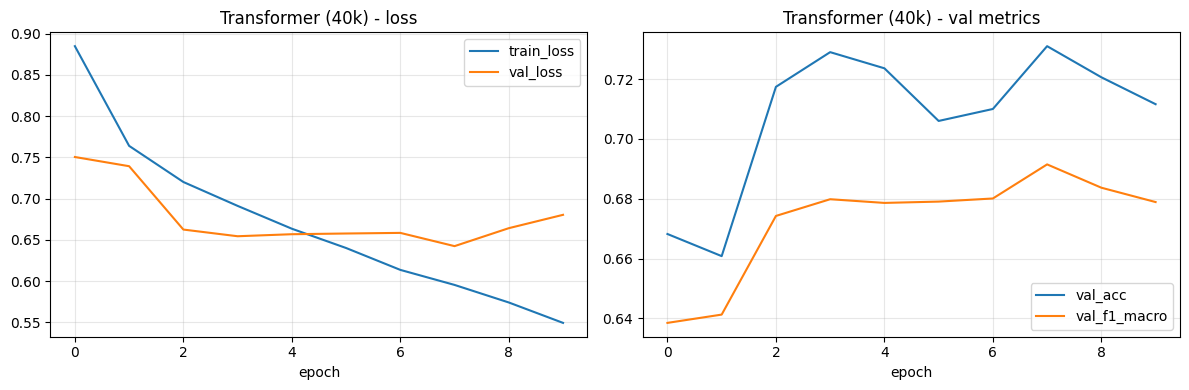


              precision    recall  f1-score   support

    negativo       0.81      0.77      0.79      2000
      neutro       0.42      0.51      0.46      1000
    positivo       0.85      0.81      0.83      2000

    accuracy                           0.73      5000
   macro avg       0.69      0.69      0.69      5000
weighted avg       0.75      0.73      0.74      5000



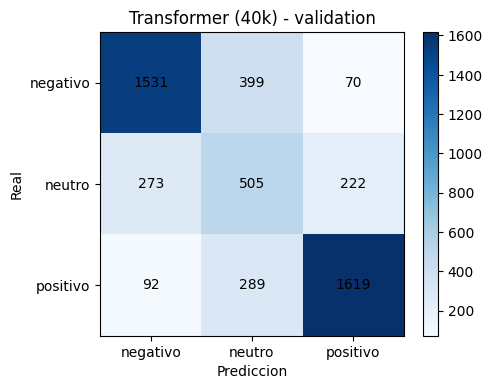

In [27]:
transformer_model = build_transformer()
print(f"Transformer -> {count_params(transformer_model):,} parametros entrenables")

transformer_model, transformer_history, tr_val_acc, tr_val_f1, tr_val_preds, tr_val_labels = train_and_report(
    transformer_model, "Transformer (40k)",
)
plot_training_curves(transformer_history, 'Transformer (40k)')

print()
print(classification_report(tr_val_labels, tr_val_preds, target_names=CLASS_NAMES))
plot_confusion(tr_val_labels, tr_val_preds, CLASS_NAMES, 'Transformer (40k) - validation')

### Tabla comparativa E1

In [28]:
comparison_e1 = pd.DataFrame([
    {'modelo': 'TF-IDF + LogReg', 'val_acc': tfidf_val_acc, 'val_f1_macro': tfidf_val_f1,
     'parametros': None, 'fuente': 'referencia LSTM (02_RESULTADOS_LSTM.md)'},
    {'modelo': 'MLP (mean-pooled embeddings)', 'val_acc': mlp_val_acc, 'val_f1_macro': mlp_val_f1,
     'parametros': count_params(mlp_model), 'fuente': 'este notebook, 40k'},
    {'modelo': 'Transformer Encoder (base)', 'val_acc': tr_val_acc, 'val_f1_macro': tr_val_f1,
     'parametros': count_params(transformer_model), 'fuente': 'este notebook, 40k'},
])
comparison_e1

,modelo,val_acc,val_f1_macro,parametros,fuente
0,TF-IDF + LogReg,0.7382,0.696000,NaN,referencia LSTM (02_RESULTADOS_LSTM.md)
1,MLP (mean-pooled embeddings),0.7064,0.672794,2593795.0,"este notebook, 40k"
2,Transformer Encoder (base),0.7310,0.691471,2964995.0,"este notebook, 40k"


### Interpretación de E1 (resultados reales, 40k train / validation oficial)

| Modelo | val_acc | val_f1_macro | fuente |
|---|---:|---:|---|
| TF-IDF + LogReg | 0.7382 | 0.6960 | referencia LSTM |
| MLP (mean-pooled embeddings) | 0.7064 | 0.6728 | este notebook, 40k |
| Transformer Encoder (base) | 0.7310 | 0.6915 | este notebook, 40k |


1. **El Transformer le gana al MLP en ambas métricas.** Es la comparación más limpia de las tres: comparten el mismo embedding, `pad_token_id` y pooling, la única diferencia es el self-attention, y con todo lo demás igual, sí mueve la aguja.
2. **El MLP queda claramente por debajo del TF-IDF+LogReg.** No es un bug: con poco dato, un modelo lineal sobre TF-IDF trae señal fuerte "gratis", mientras el MLP tiene que aprender sus embeddings desde cero.
3. **El Transformer tampoco le gana al TF-IDF+LogReg** (0.7310/0.6915 vs 0.7382/0.6960), quedan casi empatados, con el TF-IDF levemente adelante. Ya es una señal temprana de lo que se confirma en el resto del notebook: cerrar esa distancia no va a ser trivial.

## Experimento E2: efecto de la cantidad de datos (40k / 80k / 200k)

**Pregunta:** ¿el Transformer se beneficia de más datos de entrenamiento de forma similar (o más) que el BiLSTM?

**Hipótesis:** un Transformer tiene menos sesgo inductivo que una red recurrente, no asume localidad secuencial, tiene que aprenderlo todo vía self-attention, así que debería depender más de la cantidad de datos. Esperamos que `val_f1_macro` mejore de forma monótona de 40k a 200k, con una pendiente incluso más pronunciada que la del BiLSTM.

**Variable que cambia:** únicamente `train_size` (40k / 80k / 200k). **Se controla:** el resto, arquitectura, `MAX_LEN`, `vocab_size`, `batch_size`, `num_epochs`/`patience`, optimizador y seed.

**El punto de 40k no se reentrena:** con la misma seed, `get_train_subset` selecciona las mismas filas que `train_40k` en E1, es literalmente la misma corrida que E1c. Reusamos ese resultado (`val_acc=0.7310`, `val_f1_macro=0.6915`) y solo entrenamos 80k y 200k.

**Referencia externa** de BiLSTM mean+max con el proyecto de LSTM):

| train_size | val_acc | val_f1_macro |
|---:|---:|---:|
| 40k | 0.7404 | 0.7046 |
| 80k | 0.7450 | 0.7126 |
| 200k | 0.7588 | 0.7300 |

**Costo esperado:** a `batch_size=64`, cada epoch son 625/1250/3125 pasos para 40k/80k/200k. La corrida de 200k es, por lejos, la más costosa de todo el notebook.

In [29]:
DATA_SIZES = [80_000, 200_000]  # 40k no se repite: es exactamente lo que ya entrenamos en E1c

e2_results = [
    {'train_size': 40_000, 'val_acc': 0.7310, 'val_f1_macro': 0.691471},  # = E1c, mismo seed y mismos datos
]
for n in DATA_SIZES:
    print(f"\n=== E2: entrenando Transformer con {n} ejemplos de train ===")
    train_subset_n = get_train_subset(train_raw, n)
    class_weights_n = compute_class_weights(train_subset_n['sentiment'])
    loader_n = DataLoader(
        SentimentDataset(train_subset_n, final_tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    )

    # `model_n` queda en memoria al terminar el loop apuntando a la ultima
    # iteracion (200k) -- es el modelo que reusamos mas adelante en la
    # evaluacion final de test, para no reentrenar de nuevo.
    model_n, history_n, acc_n, f1_n, _, _ = train_and_report(
        build_transformer(), f"Transformer ({n})", loader=loader_n, weights=class_weights_n,
    )
    e2_results.append({'train_size': n, 'val_acc': acc_n, 'val_f1_macro': f1_n})

e2_df = pd.DataFrame(e2_results)
e2_df


=== E2: entrenando Transformer con 80000 ejemplos de train ===
Epoch 1/10 - train_loss=0.8394 val_loss=0.7230 val_acc=0.6790 val_f1_macro=0.6507 lr=3.00e-04
Epoch 2/10 - train_loss=0.7250 val_loss=0.6654 val_acc=0.7176 val_f1_macro=0.6742 lr=3.00e-04
Epoch 3/10 - train_loss=0.6858 val_loss=0.6717 val_acc=0.6932 val_f1_macro=0.6739 lr=3.00e-04
Epoch 4/10 - train_loss=0.6582 val_loss=0.6388 val_acc=0.7240 val_f1_macro=0.6857 lr=3.00e-04
Epoch 5/10 - train_loss=0.6369 val_loss=0.6322 val_acc=0.7366 val_f1_macro=0.6975 lr=3.00e-04
Epoch 6/10 - train_loss=0.6140 val_loss=0.6565 val_acc=0.7130 val_f1_macro=0.6863 lr=3.00e-04
Epoch 7/10 - train_loss=0.5966 val_loss=0.6366 val_acc=0.7338 val_f1_macro=0.6971 lr=3.00e-04
Epoch 8/10 - train_loss=0.5793 val_loss=0.6804 val_acc=0.6938 val_f1_macro=0.6736 lr=3.00e-04
Early stopping en epoch 8 (sin mejora en val_f1_macro por 3 epochs)
Transformer (80000) -> val_acc=0.7366 val_f1_macro=0.6975

=== E2: entrenando Transformer con 200000 ejemplos de tra

,train_size,val_acc,val_f1_macro
0,40000,0.7310,0.691471
1,80000,0.7366,0.697524
2,200000,0.7466,0.712586


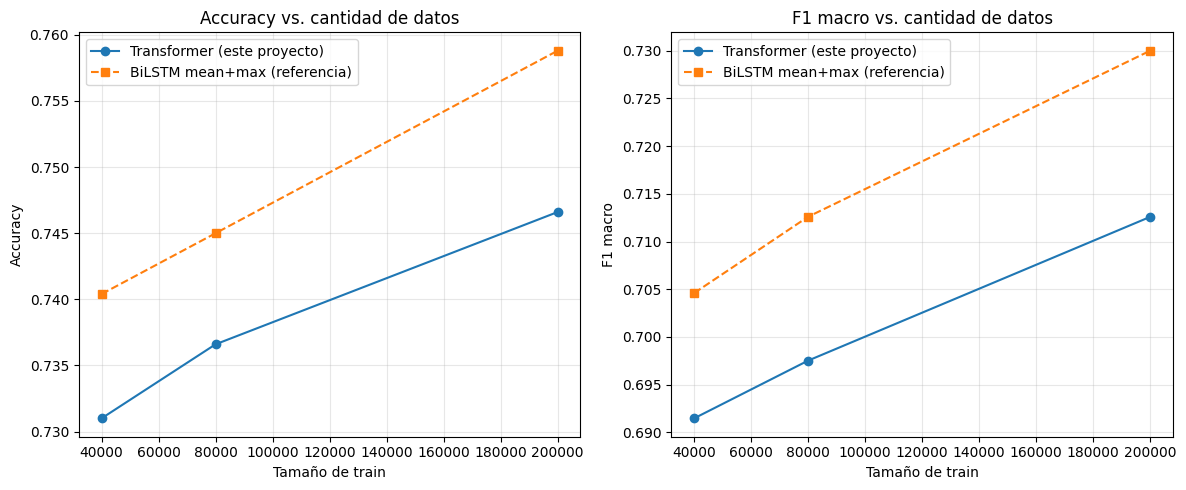

In [30]:
lstm_reference_e2 = pd.DataFrame([
    {'train_size': 40_000, 'val_acc': 0.7404, 'val_f1_macro': 0.7046},
    {'train_size': 80_000, 'val_acc': 0.7450, 'val_f1_macro': 0.7126},
    {'train_size': 200_000, 'val_acc': 0.7588, 'val_f1_macro': 0.7300},
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, title in zip(axes, ['val_acc', 'val_f1_macro'], ['Accuracy', 'F1 macro']):
    ax.plot(e2_df['train_size'], e2_df[metric], marker='o', label='Transformer (este proyecto)')
    ax.plot(lstm_reference_e2['train_size'], lstm_reference_e2[metric], marker='s', linestyle='--',
            label='BiLSTM mean+max (referencia)')
    ax.set_xlabel('Tamaño de train')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs. cantidad de datos')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de E2 (resultados reales)

| train_size | val_acc | val_f1_macro | BiLSTM F1 (referencia) | Brecha |
|---:|---:|---:|---:|---:|
| 40,000 | 0.7310 | 0.6915 | 0.7046 | 0.0131 |
| 80,000 | 0.7366 | 0.6975 | 0.7126 | 0.0151 |
| 200,000 | 0.7466 | 0.7126 | 0.7300 | 0.0174 |

**La hipótesis no se confirma.** Esperábamos que el Transformer aprovechara mejor los datos extra y cerrara la brecha. Pasó lo contrario: el BiLSTM gana más F1 macro entre 40k y 200k (+0.0254) que el Transformer (+0.0211), y la brecha se agranda (0.0131 → 0.0151 → 0.0174).

**Posibles explicaciones**, a confirmar en los experimentos que siguen:

1. **Las reseñas son cortas** (p95=89 tokens): la ventaja del self-attention es capturar dependencias de largo alcance, y eso pesa menos cuando una recurrencia bidireccional ya cubre bien la secuencia.
2. **No es una comparación de esfuerzo equivalente.** El BiLSTM mean+max ya es la mejor variante tras varias iteraciones de diseño; nuestro Transformer sigue en su config base.
3. **Sin warmup/scheduler de LR.** Entrenamos con AdamW a tasa constante; el paper original usa warmup + decay.

## Experimento E3: efecto de la estrategia de pooling (mean / max / cls)

**Pregunta:** ¿qué tanto importa cómo se agregan los vectores de salida del encoder en un solo vector para clasificar?

**Hipótesis:** motivada por el LSTM, donde el pooling importó más que la profundidad. Esperamos un efecto notable acá también:
- **mean** (E1/E2): agrega toda la secuencia por igual, robusto pero puede diluir señales puntuales ("pésimo", "excelente").
- **max**: toma el máximo por dimensión, podría capturar mejor señales localizadas — parecido al mean+max que le funcionó al BiLSTM.
- **cls**: un token aprendible que decide qué agregar vía self-attention, el enfoque de BERT.

**Variable que cambia:** el pooling. **Se controla:** todo lo demás, sobre el mismo subset de 40k. **`mean` no se reentrena** (es la base, ya la corrimos en E1c) — solo entrenamos `max` y `cls`.

In [31]:
POOLING_VARIANTS = ['max', 'cls']  # 'mean' no se repite: es exactamente la base entrenada en E1c

e3_results = [
    {'pooling': 'mean', 'val_acc': 0.7310, 'val_f1_macro': 0.691471, 'parametros': 2_964_995},  # = E1c
]
for pooling in POOLING_VARIANTS:
    print(f"\n=== E3: entrenando Transformer con pooling='{pooling}' (40k) ===")
    model_p, history_p, acc_p, f1_p, _, _ = train_and_report(
        build_transformer(pooling=pooling), f"Transformer (pooling={pooling})",
    )
    e3_results.append({
        'pooling': pooling, 'val_acc': acc_p, 'val_f1_macro': f1_p, 'parametros': count_params(model_p),
    })

e3_df = pd.DataFrame(e3_results)
e3_df


=== E3: entrenando Transformer con pooling='max' (40k) ===
Epoch 1/10 - train_loss=0.8935 val_loss=0.7522 val_acc=0.6740 val_f1_macro=0.6383 lr=3.00e-04
Epoch 2/10 - train_loss=0.7647 val_loss=0.7370 val_acc=0.6730 val_f1_macro=0.6470 lr=3.00e-04
Epoch 3/10 - train_loss=0.7123 val_loss=0.6585 val_acc=0.7244 val_f1_macro=0.6784 lr=3.00e-04
Epoch 4/10 - train_loss=0.6808 val_loss=0.6464 val_acc=0.7240 val_f1_macro=0.6717 lr=3.00e-04
Epoch 5/10 - train_loss=0.6492 val_loss=0.6498 val_acc=0.7258 val_f1_macro=0.6772 lr=3.00e-04
Epoch 6/10 - train_loss=0.6251 val_loss=0.6491 val_acc=0.7242 val_f1_macro=0.6894 lr=3.00e-04
Epoch 7/10 - train_loss=0.5953 val_loss=0.6458 val_acc=0.7314 val_f1_macro=0.6924 lr=3.00e-04
Epoch 8/10 - train_loss=0.5709 val_loss=0.6766 val_acc=0.7006 val_f1_macro=0.6768 lr=3.00e-04
Epoch 9/10 - train_loss=0.5488 val_loss=0.6513 val_acc=0.7322 val_f1_macro=0.6874 lr=3.00e-04
Epoch 10/10 - train_loss=0.5254 val_loss=0.6585 val_acc=0.7386 val_f1_macro=0.6887 lr=3.00e-04

,pooling,val_acc,val_f1_macro,parametros
0,mean,0.7310,0.691471,2964995
1,max,0.7314,0.692372,2964995
2,cls,0.7244,0.687327,2965123


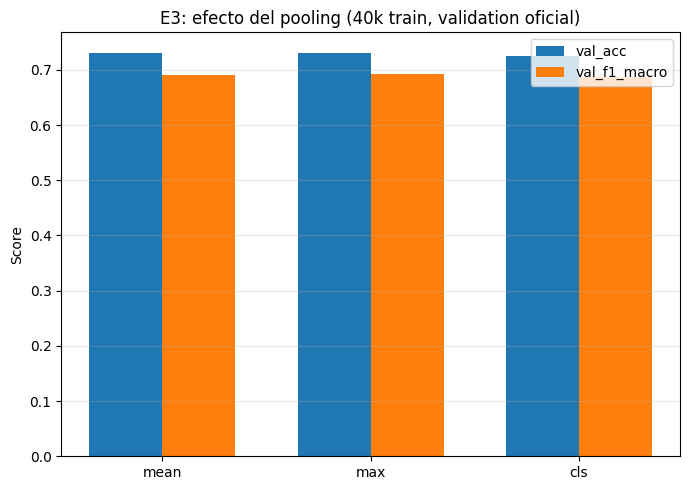

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(e3_df))
width = 0.35
ax.bar(x - width / 2, e3_df['val_acc'], width, label='val_acc')
ax.bar(x + width / 2, e3_df['val_f1_macro'], width, label='val_f1_macro')
ax.set_xticks(x)
ax.set_xticklabels(e3_df['pooling'])
ax.set_ylabel('Score')
ax.set_title('E3: efecto del pooling (40k train, validation oficial)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Interpretación de E3 (resultados reales)

| pooling | val_acc | val_f1_macro | parámetros |
|---|---:|---:|---:|
| mean | 0.7310 | 0.6915 | 2,964,995 |
| max | 0.7314 | 0.6924 | 2,964,995 |
| cls | 0.7244 | 0.6873 | 2,965,123 |

A diferencia del LSTM, acá **el pooling casi no cambia nada**. `mean` y `max` quedan prácticamente empatados (+0.09pp de F1 macro, ruido más que señal), y `cls` sale un poco peor (-0.4pp) pese a tener 128 parámetros más. Tiene sentido: con solo 2 capas, 40k ejemplos y 10 epochs, un token `[CLS]` al azar tiene que aprender desde cero a "resumir" la secuencia.

Esto descarta al pooling como explicación de la brecha con el BiLSTM (0.0131 de F1 macro a 40k, ver E2). Seguimos con `mean` por defecto para el resto de los experimentos.

## Experimento E4: warmup + decay de learning rate

Ni E2 (más datos) ni E3 (pooling) cerraron la brecha con el BiLSTM. De las tres explicaciones de E2, la que falta probar es que entrenamos con `AdamW` a **tasa constante**, mientras "Attention is All You Need" usa **warmup lineal + decaimiento**.

**Pregunta:** ¿el schedule de LR del paper mejora el desempeño frente a LR constante?

**Variable que cambia:** el schedule (mismo `lr` pico = 3e-4), sobre el mismo subset de 40k. **Comparación "sin warmup":** reusamos el resultado de E1/E3 (`val_acc=0.7310`, `val_f1_macro=0.6915`) — no hace falta reentrenarlo.

In [33]:
model_warmup, history_warmup, acc_warmup, f1_warmup, _, _ = train_and_report(
    build_transformer(), "Transformer (warmup+decay, 40k)", use_lr_warmup=True, warmup_ratio=0.1,
)

Epoch 1/10 - train_loss=0.9735 val_loss=0.7887 val_acc=0.6582 val_f1_macro=0.6164 lr=3.00e-04
Epoch 2/10 - train_loss=0.7937 val_loss=0.7432 val_acc=0.6684 val_f1_macro=0.6366 lr=2.12e-04
Epoch 3/10 - train_loss=0.7375 val_loss=0.6899 val_acc=0.7006 val_f1_macro=0.6628 lr=1.73e-04
Epoch 4/10 - train_loss=0.7082 val_loss=0.6792 val_acc=0.7078 val_f1_macro=0.6681 lr=1.50e-04
Epoch 5/10 - train_loss=0.6865 val_loss=0.6645 val_acc=0.7160 val_f1_macro=0.6713 lr=1.34e-04
Epoch 6/10 - train_loss=0.6693 val_loss=0.6781 val_acc=0.6916 val_f1_macro=0.6671 lr=1.22e-04
Epoch 7/10 - train_loss=0.6543 val_loss=0.6766 val_acc=0.6962 val_f1_macro=0.6703 lr=1.13e-04
Epoch 8/10 - train_loss=0.6414 val_loss=0.6528 val_acc=0.7240 val_f1_macro=0.6852 lr=1.06e-04
Epoch 9/10 - train_loss=0.6321 val_loss=0.6695 val_acc=0.7068 val_f1_macro=0.6768 lr=1.00e-04
Epoch 10/10 - train_loss=0.6163 val_loss=0.6703 val_acc=0.7056 val_f1_macro=0.6774 lr=9.49e-05
Transformer (warmup+decay, 40k) -> val_acc=0.7240 val_f1_ma

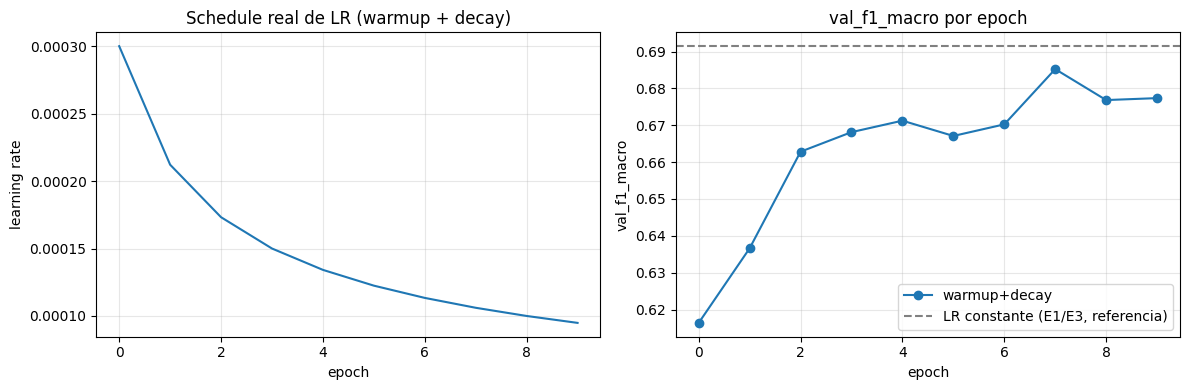

,schedule,val_acc,val_f1_macro
0,LR constante (E1/E3),0.731,0.691471
1,warmup + decay,0.724,0.685243


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_warmup['lr'])
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('learning rate')
axes[0].set_title('Schedule real de LR (warmup + decay)')
axes[0].grid(alpha=0.3)

axes[1].plot(history_warmup['val_f1_macro'], marker='o', label='warmup+decay')
axes[1].axhline(0.691471, linestyle='--', color='gray', label='LR constante (E1/E3, referencia)')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('val_f1_macro')
axes[1].set_title('val_f1_macro por epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

lr_comparison = pd.DataFrame([
    {'schedule': 'LR constante (E1/E3)', 'val_acc': 0.7310, 'val_f1_macro': 0.691471},
    {'schedule': 'warmup + decay', 'val_acc': acc_warmup, 'val_f1_macro': f1_warmup},
])
lr_comparison

### Interpretación de E4 (resultados reales)

| schedule | val_acc | val_f1_macro |
|---|---:|---:|
| LR constante | 0.7310 | 0.6915 |
| warmup + decay | 0.7240 | 0.6852 |

**Salió peor**, pero no porque el warmup no funcione — es un detalle de cómo interactúan `warmup_ratio=0.1` con un presupuesto corto de 10 epochs: con 625 pasos/epoch, `total_steps=6250` y `warmup_steps=625`, la subida completa ocurre dentro del primer epoch (por eso no se ve en el gráfico, que solo loguea al final de cada epoch), y las 9 epochs restantes el LR decae de 3e-4 a 9.49e-05 (3e-4 x sqrt(625/6250) = 9.49e-05, coincide exacto con lo que imprimió la epoch 10). La corrida con warmup pasó por el pico de LR una sola vez, mientras la constante usó 3e-4 las 10 epochs completas — con el mismo presupuesto, eso es literalmente menos empuje de gradiente acumulado.

## Experimento E5: capacidad del modelo (num_layers / num_heads)

**Pregunta:** de las tres explicaciones de E2, falta probar si el Transformer base (2 capas, 4 heads, ~3M parámetros) está limitado en capacidad.

**Hipótesis:** si la capacidad es el cuello de botella, más capas debería acercar `val_f1_macro` al del BiLSTM. `num_heads` en cambio **no** agrega parámetros acá (las proyecciones Q/K/V/salida siguen siendo `d_model x d_model`), así que esa variante prueba si diversificar las "vistas" de atención ayuda, no la capacidad en sí.

**Variantes:** `base (2L/4H)` (de E1/E3), `deeper (4L/4H)`, `wider heads (2L/8H)`. **Se controla:** todo lo demás, sobre el mismo subset de 40k. **Referencia:** BiLSTM a 40k, `val_f1_macro=0.7046` vs. nuestra base en 0.6915 (brecha de 0.0131).

In [35]:
CAPACITY_VARIANTS = [
    {'name': 'deeper (4L/4H)', 'num_layers': 4, 'num_heads': 4},
    {'name': 'wider heads (2L/8H)', 'num_layers': 2, 'num_heads': 8},
]

e5_results = [
    {'config': 'base (2L/4H)', 'num_layers': NUM_LAYERS, 'num_heads': NUM_HEADS,
     'val_acc': 0.7310, 'val_f1_macro': 0.691471, 'parametros': 2_964_995},
]

for variant in CAPACITY_VARIANTS:
    print(f"\n=== E5: entrenando Transformer {variant['name']} (40k) ===")
    model_c, history_c, acc_c, f1_c, _, _ = train_and_report(
        build_transformer(num_layers=variant['num_layers'], num_heads=variant['num_heads']),
        f"Transformer {variant['name']}",
    )
    e5_results.append({
        'config': variant['name'], 'num_layers': variant['num_layers'], 'num_heads': variant['num_heads'],
        'val_acc': acc_c, 'val_f1_macro': f1_c, 'parametros': count_params(model_c),
    })

e5_df = pd.DataFrame(e5_results)
e5_df


=== E5: entrenando Transformer deeper (4L/4H) (40k) ===
Epoch 1/10 - train_loss=0.8863 val_loss=0.7639 val_acc=0.6532 val_f1_macro=0.6216 lr=3.00e-04
Epoch 2/10 - train_loss=0.7671 val_loss=0.7263 val_acc=0.6686 val_f1_macro=0.6412 lr=3.00e-04
Epoch 3/10 - train_loss=0.7196 val_loss=0.6752 val_acc=0.7216 val_f1_macro=0.6729 lr=3.00e-04
Epoch 4/10 - train_loss=0.6849 val_loss=0.6735 val_acc=0.6916 val_f1_macro=0.6663 lr=3.00e-04
Epoch 5/10 - train_loss=0.6575 val_loss=0.6842 val_acc=0.6954 val_f1_macro=0.6714 lr=3.00e-04
Epoch 6/10 - train_loss=0.6323 val_loss=0.6699 val_acc=0.7084 val_f1_macro=0.6793 lr=3.00e-04
Epoch 7/10 - train_loss=0.6048 val_loss=0.7130 val_acc=0.6780 val_f1_macro=0.6618 lr=3.00e-04
Epoch 8/10 - train_loss=0.5825 val_loss=0.6649 val_acc=0.7278 val_f1_macro=0.6813 lr=3.00e-04
Epoch 9/10 - train_loss=0.5584 val_loss=0.7086 val_acc=0.7120 val_f1_macro=0.6732 lr=3.00e-04
Epoch 10/10 - train_loss=0.5359 val_loss=0.7436 val_acc=0.6890 val_f1_macro=0.6644 lr=3.00e-04
Tr

,config,num_layers,num_heads,val_acc,val_f1_macro,parametros
0,base (2L/4H),2,4,0.7310,0.691471,2964995
1,deeper (4L/4H),4,4,0.7278,0.681331,3361539
2,wider heads (2L/8H),2,8,0.7232,0.682425,2964995


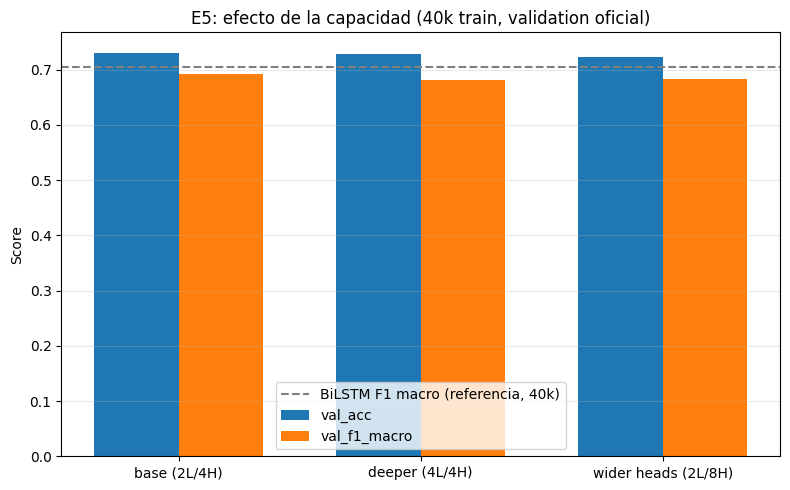

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(e5_df))
width = 0.35
ax.bar(x - width / 2, e5_df['val_acc'], width, label='val_acc')
ax.bar(x + width / 2, e5_df['val_f1_macro'], width, label='val_f1_macro')
ax.axhline(0.7046, linestyle='--', color='gray', label='BiLSTM F1 macro (referencia, 40k)')
ax.set_xticks(x)
ax.set_xticklabels(e5_df['config'])
ax.set_ylabel('Score')
ax.set_title('E5: efecto de la capacidad (40k train, validation oficial)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Interpretación de E5 (resultados reales)

| config | num_layers | num_heads | val_acc | val_f1_macro | parámetros |
|---|---:|---:|---:|---:|---:|
| base (2L/4H) | 2 | 4 | 0.7310 | 0.6915 | 2,964,995 |
| deeper (4L/4H) | 4 | 4 | 0.7278 | 0.6813 | 3,361,539 |
| wider heads (2L/8H) | 2 | 8 | 0.7232 | 0.6824 | 2,964,995 |

**Las dos variantes empeoran**, no solo no ayudan. `deeper` pierde 1.01pp de F1 macro pese a tener 13.4% más parámetros — con solo 40k ejemplos, más capacidad probablemente empieza a sobreajustar, y es más difícil de optimizar en el mismo presupuesto sin warmup (conecta con la prueba anterior). `wider heads` pierde 0.90pp con **los mismos parámetros** que la base, lo que descarta el sobreajuste: con `d_model=128`, 8 cabezas de 16 dimensiones parecen ser demasiado angostas para aportar algo por separado.

### Balance de las cuatro pruebas para explicar la brecha con el BiLSTM

| Explicación probada | Resultado |
|---|---|
| Más datos (E2, 40k→200k) | No cierra la brecha, se agranda levemente (0.0131 → 0.0174) |
| Pooling (E3: mean/max/cls) | Sin efecto significativo |
| LR warmup+decay (E4) | Empeora (mismatch de presupuesto corto) |
| Capacidad (E5: más capas / más heads) | Empeora en ambas variantes |

Cuatro pruebas, cuatro resultados que no cierran la brecha — la última incluso la agranda. Esto es evidencia consistente de que la brecha es probablemente **estructural** (reseñas cortas, p95=89 tokens, donde una recurrencia bidireccional ya cubre bien el contexto) y/o de **esfuerzo de afinamiento desigual** (el BiLSTM ya pasó por varias iteraciones de diseño; nuestro Transformer sigue en su primera configuración razonada, sin búsqueda de hiperparámetros).

## Evaluación final en test

Este es el **único** uso del split de test en todo el notebook, con un **único modelo ya decidido con validation**: el Transformer de E2 con 200k ejemplos (pooling=`mean`, base 2L/4H, LR constante), el mejor resultado de todos los experimentos (`val_f1_macro=0.7126`). No se reentrena ni se ajusta nada después de ver estos números.

In [37]:
final_model = model_n  # modelo de 200k, pooling=mean, 2L/4H, LR constante
assert isinstance(final_model, TransformerClassifier), (
    "model_n no esta definido o no es el esperado -- vuelve a correr el loop de E2 "
    "(punto de 200k) antes de continuar."
)

n_layers = len(final_model.encoder.layers)
n_heads = final_model.encoder.layers[0].self_attn.num_heads
print(f"Modelo final -> pooling={final_model.pooling}, num_layers={n_layers}, "
      f"num_heads={n_heads}, parametros={count_params(final_model):,}")

Modelo final -> pooling=mean, num_layers=2, num_heads=4, parametros=2,964,995


Transformer final (200k) en TEST -> acc=0.7498 f1_macro=0.7146

              precision    recall  f1-score   support

    negativo       0.84      0.78      0.81      2000
      neutro       0.45      0.56      0.50      1000
    positivo       0.86      0.82      0.84      2000

    accuracy                           0.75      5000
   macro avg       0.72      0.72      0.71      5000
weighted avg       0.77      0.75      0.76      5000



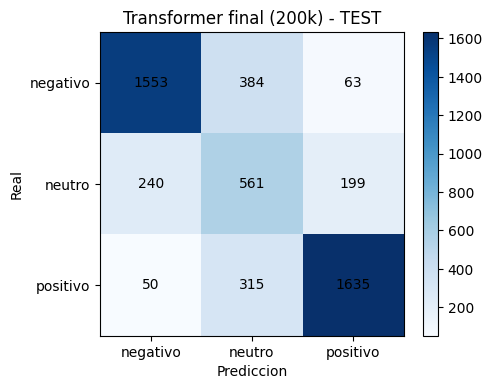

In [38]:
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate_model(
    final_model, test_loader, nn.CrossEntropyLoss(),
)
print(f"Transformer final (200k) en TEST -> acc={test_acc:.4f} f1_macro={test_f1:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
plot_confusion(test_labels, test_preds, CLASS_NAMES, 'Transformer final (200k) - TEST')

In [39]:
final_test_comparison = pd.DataFrame([
    {'modelo': 'TF-IDF + LogReg', 'test_acc': 0.7502, 'test_f1_macro': 0.7075, 'fuente': 'referencia LSTM'},
    {'modelo': 'BiLSTM mean+max (200k)', 'test_acc': 0.7634, 'test_f1_macro': 0.7324, 'fuente': 'referencia LSTM'},
    {'modelo': 'Mejor config. LSTM (Parte 2)', 'test_acc': 0.7734, 'test_f1_macro': 0.7383, 'fuente': 'referencia LSTM'},
    {'modelo': 'Transformer (este proyecto, 200k)', 'test_acc': test_acc, 'test_f1_macro': test_f1, 'fuente': 'este notebook'},
])
final_test_comparison

,modelo,test_acc,test_f1_macro,fuente
0,TF-IDF + LogReg,0.7502,0.707500,referencia LSTM
1,BiLSTM mean+max (200k),0.7634,0.732400,referencia LSTM
2,Mejor config. LSTM (Parte 2),0.7734,0.738300,referencia LSTM
3,"Transformer (este proyecto, 200k)",0.7498,0.714597,este notebook


## Análisis de errores (test)

Revisamos en qué se equivoca el modelo: frecuencia de errores, entre qué clases se confunde más, y ejemplos cualitativos.

In [40]:
test_texts = list(test_raw['text'])

errors_df = pd.DataFrame({
    'texto': test_texts,
    'real': [CLASS_NAMES[l] for l in test_labels],
    'prediccion': [CLASS_NAMES[p] for p in test_preds],
})
errors_df = errors_df[errors_df['real'] != errors_df['prediccion']].reset_index(drop=True)

print(f"Errores: {len(errors_df)} de {len(test_texts)} ({len(errors_df) / len(test_texts) * 100:.1f}%)")

error_breakdown = (
    errors_df.groupby(['real', 'prediccion']).size().reset_index(name='count').sort_values('count', ascending=False)
)
error_breakdown

Errores: 1251 de 5000 (25.0%)


,real,prediccion,count
0,negativo,neutro,384
5,positivo,neutro,315
2,neutro,negativo,240
3,neutro,positivo,199
1,negativo,positivo,63
4,positivo,negativo,50


In [41]:
pd.set_option('display.max_colwidth', 150)
errors_df.sample(15, random_state=SEED)[['texto', 'real', 'prediccion']]

,texto,real,prediccion
721,Bien para iniciarte y en calidad-precio\n\nCumple su función y en relación calidad-precio no se puede pedir más. Es ideal para iniciarte en este m...,neutro,positivo
1243,"Depende para que las quieras usar\n\nSi quieres patear un poco sin demasiada fuerza, tipo artes marciales, perfectas. Pero para golpear fuerte no ...",positivo,neutro
1067,"Funcional pero sin apagado automatico\n\nMe parece una tostadora muy práctica, sobre todo por la tapa de plastico, que impide quede al aire todo e...",positivo,neutro
901,"Buen precio, pero sobra una toma.\n\nCarga varios dispositivos a la vez. Pero la toma de Apple, no sirve. No carga.",positivo,neutro
1107,"Relación calidad precio buena\n\nLa correa queda bien, pero en uno de los lados fue más difícil de montar. El palillo no entraba bien por los aguj...",positivo,neutro
1217,Una forma especial para cargar la batería\n\nCuando abrir el paquete me ha sorprendido mucho por su forma de cargar la batería. Pensaba que falta ...,positivo,neutro
682,"Engaña\n\nMuy fino, abriga poco",neutro,negativo
712,El protector delantero mejor no poner nada\n\nEl protector trasero no esta mal pro el delantero para eso mejor no poner nada,neutro,negativo
701,El velcro falla al cabo de no mucho tiempo\n\nUna maravilla de diseño y cómodas pero el velcro me ha fallado a las pocas semanas ... Una lástima p...,neutro,negativo
196,"🤷‍♀️\n\nPensaba que en el libro, la autora explicaría su experiéncia, sus sentimientos, la historia que está viviendo desde que entró en OT. Pensa...",negativo,positivo


### Interpretación (resultados reales)

**Test final:** `test_acc=0.7498`, `test_f1_macro=0.7146`.

| modelo | test_acc | test_f1_macro | fuente |
|---|---:|---:|---|
| TF-IDF + LogReg | 0.7502 | 0.7075 | referencia LSTM |
| **Transformer (este proyecto, 200k)** | **0.7498** | **0.7146** | este notebook |
| BiLSTM mean+max (200k) | 0.7634 | 0.7324 | referencia LSTM |
| Mejor config. LSTM (Parte 2) | 0.7734 | 0.7383 | referencia LSTM |

El Transformer finalmente le gana al TF-IDF+LogReg en F1 macro (+0.71pp), aunque en accuracy quedan prácticamente empatados. Es notable porque en E1 (40k) pasaba lo contrario — con los 200k datos completos el self-attention sí termina aportando algo frente al baseline más simple, la única comparación de todo el proyecto donde el Transformer supera a un baseline clásico. Sigue detrás de las dos variantes de BiLSTM (-1.78pp y -2.37pp de F1 macro).

**`neutro` sigue siendo, por lejos, la clase más difícil** (F1=0.50, precision=0.45, recall=0.56) frente a 0.81 (negativo) y 0.84 (positivo) — el mismo patrón que encontró el LSTM.

De los 1,251 errores en test, **1,138 (91%) son confusiones con `neutro`** (negativo↔neutro: 624; positivo↔neutro: 514), y solo **113 (9%) son errores "graves"** entre polos opuestos (negativo↔positivo). Cuando el modelo se equivoca, casi siempre lo hace por un escalón, no invirtiendo el sentimiento por completo.

**Cualitativamente**, domina la reseña con sentimiento mixto o concesivo — "Buen precio, pero la toma de Apple no sirve", "Relación calidad precio buena, pero... fue más difícil de montar", "Una maravilla de diseño... pero el velcro me ha fallado". El texto da señales contradictorias y la estrella asignada refleja un juicio global que no siempre coincide con la señal textual dominante.

## **Conclusiones**

**Sobre la pregunta del proyecto**: ¿cómo se comporta un Transformer Encoder frente a TF-IDF, MLP y LSTM/BiLSTM, y qué efecto tienen las decisiones arquitectónicas y la cantidad de datos?):

1. **El self-attention sí aporta, aislado de todo lo demás.** En E1, el Transformer le gana al MLP que comparte exactamente el mismo embedding y pooling — la única diferencia es el self-attention. Esa es la comparación más limpia del notebook y el resultado más sólido a favor de la arquitectura.

2. **Ganarle a un baseline maduro no es fácil.** Ni el TF-IDF+LogReg del LSTM (E1) ni el BiLSTM mean+max (E2 en adelante) quedaron atrás del Transformer base. Probamos cuatro experimentos distintas para cerrar esa brecha — más datos (E2), estrategia de pooling (E3), el schedule de LR del paper original (E4), y más capacidad (E5) — y ninguna la cerró; la de capacidad incluso la agrandó.

3. **La explicación más consistente con la evidencia es estructural, no de ajuste.** Las reseñas de este dataset son cortas (p95=89 tokens): una recurrencia bidireccional ya cubre razonablemente bien el contexto de la secuencia, así que la ventaja distintiva del self-attention, modelar dependencias de largo alcance sin la limitación de una ventana local, tiene menos terreno donde mostrarse.

4. **En test, el Transformer (200k) obtiene `test_acc=0.7498` y `test_f1_macro=0.7146`.** Empata en accuracy con TF-IDF+LogReg (0.7502) pero lo supera en F1 macro (+0.71pp), la única comparación de todo el proyecto donde el Transformer le gana a un baseline clásico. Sigue detrás del BiLSTM mean+max (0.7324, -1.78pp) y de la mejor configuración del LSTM (0.7383, -2.37pp). Con suficiente dato, el self-attention sí aporta algo frente al baseline más simple, aunque no alcanza para cerrar la distancia con las arquitecturas recurrentes más afinadas.

5. **El análisis de errores confirma el patrón del LSTM: `neutro` es, por lejos, la clase más difícil** (F1=0.50 frente a 0.81 de negativo y 0.84 de positivo). El 91% de los 1,251 errores en test son confusiones con `neutro`; los errores "graves" entre polos opuestos son solo el 9%. Cualitativamente, la mayoría son reseñas con sentimiento mixto o concesivo ("buen precio, pero...") donde el texto da señales contradictorias y la estrella asignada no siempre coincide con la señal textual dominante, el mismo ruido entre estrellas y sentimiento que ya señalaba el proyecto LSTM.

**Del paso conceptual de RNN a Transformer** que motivaba este proyecto: más parámetros y menos sesgo inductivo no es automáticamente mejor. Para clasificación de sentimiento sobre reseñas cortas y entrenado desde cero, el sesgo inductivo de una red recurrente resultó ser un activo real, no solo un enfoque superado. Eso no invalida al Transformer, probablemente sería distinto con textos más largos, más datos, o partiendo de un modelo preentrenado.